In [181]:
import numpy as np
import pandas as pd

df = pd.read_csv(r'C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv')
df['date'] = pd.to_datetime(df['date'])
df.sort_values(by=['indicator', 'date'], inplace=True)

# Limit to the last 100 unique dates
latest_dates = df['date'].drop_duplicates().sort_values().tail(100)
df = df[df['date'].isin(latest_dates)]

df[df['indicator'] == '146.71.50.198']

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
98978,818860012482918321,2025-02-13,146.71.50.198,0,3,False,13,2,0
99220,818860012482918321,2025-02-14,146.71.50.198,0,4,False,14,2,0
99462,818860012482918321,2025-02-15,146.71.50.198,0,5,True,15,2,0
99704,818860012482918321,2025-02-16,146.71.50.198,0,6,True,16,2,0
99946,818860012482918321,2025-02-17,146.71.50.198,0,0,False,17,2,0
...,...,...,...,...,...,...,...,...,...
121968,818860012482918321,2025-05-19,146.71.50.198,0,0,False,19,5,0
122210,818860012482918321,2025-05-20,146.71.50.198,0,1,False,20,5,0
122452,818860012482918321,2025-05-21,146.71.50.198,0,2,False,21,5,0
122694,818860012482918321,2025-05-22,146.71.50.198,0,3,False,22,5,0


In [182]:
# Function to extract features per indicator
def extract_time_series_features(group):
    series = group['seen'].values
    dates = group['date'].values

    indices = np.where(series == 1)[0]
    if len(indices) == 0:
        return pd.Series({
            'last_seen': len(series),
            'freq_7': 0,
            'freq_30': 0,
            'avg_gap': len(series),
            'burstiness': 0,
            'label_7': 0,
            'label_14': 0,
            'label_30': 0
        })

    last_seen = len(series) - 1 - indices[-1] # Number of days since the IP was last seen. Recent = low value. Captures recency.
    freq_7 = np.sum(series[-7:]) # Count of days seen in the last 7 days. Measures short-term activity.
    freq_30 = np.sum(series[-30:]) # Count of days seen in the last 30 days. Measures medium-term activity.
    gaps = np.diff(indices)
    avg_gap = np.mean(gaps) if len(gaps) > 0 else len(series) # Average time (in days) between two consecutive sightings. Shows periodicity.
    burstiness = (np.std(gaps) - avg_gap) / (np.std(gaps) + avg_gap) if len(gaps) > 1 else 0 # Measures how irregular or volatile the sightings are. Based on standard deviation of gaps: Ranges from -1 (very regular) to +1 (very bursty).
    label_7 = 1 if np.any(series[-7:]) else 0
    label_14 = 1 if np.any(series[-14:]) else 0
    label_30 = 1 if np.any(series[-30:]) else 0

    return pd.Series({
        'last_seen': last_seen,
        'freq_7': freq_7,
        'freq_30': freq_30,
        'avg_gap': avg_gap,
        'burstiness': burstiness,
        'label_7': label_7,
        'label_14': label_14,
        'label_30': label_30
    })

# Apply to each indicator group
features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()

C:\Users\jaskew\AppData\Local\Temp\ipykernel_22212\1570248052.py:41: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  features_df = df.groupby('indicator').apply(extract_time_series_features).reset_index()


In [183]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from lifelines import WeibullAFTFitter
from scipy.stats import expon
import numpy as np

# Copy features into a separate DataFrame for modeling
df_pred = features_df.copy()

# Define features and labels
X = df_pred[['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']]
y_7 = df_pred['label_7']
y_14 = df_pred['label_14']
y_30 = df_pred['label_30']

# Helper functions
def train_predict(model_cls, X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([('scaler', StandardScaler()), ('clf', model_cls())])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

def train_gbt(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = GradientBoostingClassifier()
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

# Logistic Regression Predictions
df_pred['logistic_7'] = train_predict(LogisticRegression, X, y_7)
df_pred['logistic_14'] = train_predict(LogisticRegression, X, y_14)
df_pred['logistic_30'] = train_predict(LogisticRegression, X, y_30)

# Gradient Boosted Tree Predictions
df_pred['gbt_7'] = train_gbt(X, y_7)
df_pred['gbt_14'] = train_gbt(X, y_14)
df_pred['gbt_30'] = train_gbt(X, y_30)

# Exponential Model (Poisson-based) P(\text{seen in } t \text{ days}) = 1 - e^{-λt}, \quad \text{where } λ = \frac{\text{freq_30}}{30}
rate = (df_pred['freq_30'] / 30).clip(lower=1e-6)
df_pred['exp_7'] = 1 - np.exp(-rate * 7)
df_pred['exp_14'] = 1 - np.exp(-rate * 14)
df_pred['exp_30'] = 1 - np.exp(-rate * 30)

# Weibull AFT Model A survival model that predicts time until next sighting.
aft_df = X.copy()
aft_df['duration'] = df_pred['avg_gap']
aft_df['event'] = y_7

aft = WeibullAFTFitter()
aft.fit(aft_df, duration_col='duration', event_col='event')

# Predict survival function at 1, 7, 14, 30 days
surv_func = aft.predict_survival_function(aft_df, times=[1, 7, 14, 30])
df_pred['weibull_today'] = 1 - surv_func.loc[1].values
df_pred['weibull_7'] = 1 - surv_func.loc[7].values
df_pred['weibull_14'] = 1 - surv_func.loc[14].values
df_pred['weibull_30'] = 1 - surv_func.loc[30].values

# Today's forecast
df_pred['exp_today'] = 1 - np.exp(-rate * 1)
df_pred['logistic_today'] = safe_train_predict(LogisticRegression, X, y_7)
df_pred['gbt_today'] = train_gbt(X, y_7)

# Merge in actual "seen" value for today's date
latest_date = df['date'].max()
today_seen = df[df['date'] == latest_date][['indicator', 'seen']].rename(columns={'seen': 'seen_today'})
df_pred = df_pred.merge(today_seen, on='indicator', how='left')

# Final output
output = df_pred[[
    'indicator', 'seen_today', 'last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness',
    'exp_today', 'exp_7', 'exp_14', 'exp_30',
    'weibull_today', 'weibull_7', 'weibull_14', 'weibull_30',
    'logistic_today', 'logistic_7', 'logistic_14', 'logistic_30',
    'gbt_today', 'gbt_7', 'gbt_14', 'gbt_30'
]]

display(output)


,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,2.0,1.0,1.0,37.5000,-0.388889,3.278390e-02,0.208110,0.372911,...,8.424032e-02,7.886088e-01,0.884265,0.884265,0.955541,0.988660,0.999974,0.999974,0.999977,0.999984
1,102.129.153.43,0,7.0,0.0,2.0,36.5000,-0.403846,6.449301e-02,0.372911,0.606759,...,2.950539e-02,4.107396e-01,0.168179,0.168179,0.642964,0.978566,0.000018,0.000018,0.999977,0.999984
2,102.129.153.71,0,29.0,0.0,1.0,15.5000,-0.097822,3.278390e-02,0.208110,0.372911,...,1.097094e-03,1.919792e-02,0.032029,0.032029,0.091480,0.668249,0.000018,0.000018,0.000021,0.999984
3,102.165.16.161,0,43.0,0.0,0.0,6.0000,-0.381966,9.999995e-07,0.000007,0.000014,...,2.764331e-05,4.880502e-04,0.008907,0.008907,0.022150,0.239101,0.000018,0.000018,0.000021,0.000027
4,103.147.185.248,0,1.0,1.0,1.0,100.0000,0.000000,3.278390e-02,0.208110,0.372911,...,5.079101e-04,8.931509e-03,0.933482,0.933482,0.954434,0.984955,0.999974,0.999974,0.999977,0.999984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,international.standardbank.com/,0,100.0,0.0,0.0,100.0000,0.000000,9.999995e-07,0.000007,0.000014,...,1.443290e-15,2.564615e-14,0.000234,0.000234,0.000026,0.000188,0.000018,0.000018,0.000021,0.000027
238,pub.marq.com/,0,9.0,0.0,1.0,9.6000,0.122880,3.278390e-02,0.208110,0.372911,...,4.758530e-01,9.999889e-01,0.137102,0.137102,0.471548,0.953634,0.000018,0.000018,0.999977,0.999984
239,realinvestmentadvice.com/,0,4.0,1.0,3.0,8.0000,0.021684,9.516258e-02,0.503415,0.753403,...,9.903301e-01,1.000000e+00,0.877074,0.877074,0.926096,0.991665,0.999974,0.999974,0.999977,0.999984
240,www.emergencylighting.com/,0,2.0,1.0,1.0,100.0000,0.000000,3.278390e-02,0.208110,0.372911,...,3.899778e-04,6.864424e-03,0.928542,0.928542,0.949033,0.983046,0.999974,0.999974,0.999977,0.999984


In [184]:
output.drop(columns=['indicator'])

,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,exp_30,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,0,2.0,1.0,1.0,37.5000,-0.388889,3.278390e-02,0.208110,0.372911,0.632121,...,8.424032e-02,7.886088e-01,0.884265,0.884265,0.955541,0.988660,0.999974,0.999974,0.999977,0.999984
1,0,7.0,0.0,2.0,36.5000,-0.403846,6.449301e-02,0.372911,0.606759,0.864665,...,2.950539e-02,4.107396e-01,0.168179,0.168179,0.642964,0.978566,0.000018,0.000018,0.999977,0.999984
2,0,29.0,0.0,1.0,15.5000,-0.097822,3.278390e-02,0.208110,0.372911,0.632121,...,1.097094e-03,1.919792e-02,0.032029,0.032029,0.091480,0.668249,0.000018,0.000018,0.000021,0.999984
3,0,43.0,0.0,0.0,6.0000,-0.381966,9.999995e-07,0.000007,0.000014,0.000030,...,2.764331e-05,4.880502e-04,0.008907,0.008907,0.022150,0.239101,0.000018,0.000018,0.000021,0.000027
4,0,1.0,1.0,1.0,100.0000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,5.079101e-04,8.931509e-03,0.933482,0.933482,0.954434,0.984955,0.999974,0.999974,0.999977,0.999984
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
237,0,100.0,0.0,0.0,100.0000,0.000000,9.999995e-07,0.000007,0.000014,0.000030,...,1.443290e-15,2.564615e-14,0.000234,0.000234,0.000026,0.000188,0.000018,0.000018,0.000021,0.000027
238,0,9.0,0.0,1.0,9.6000,0.122880,3.278390e-02,0.208110,0.372911,0.632121,...,4.758530e-01,9.999889e-01,0.137102,0.137102,0.471548,0.953634,0.000018,0.000018,0.999977,0.999984
239,0,4.0,1.0,3.0,8.0000,0.021684,9.516258e-02,0.503415,0.753403,0.950213,...,9.903301e-01,1.000000e+00,0.877074,0.877074,0.926096,0.991665,0.999974,0.999974,0.999977,0.999984
240,0,2.0,1.0,1.0,100.0000,0.000000,3.278390e-02,0.208110,0.372911,0.632121,...,3.899778e-04,6.864424e-03,0.928542,0.928542,0.949033,0.983046,0.999974,0.999974,0.999977,0.999984


In [185]:
output[output['indicator'] == '102.129.153.158']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
0,102.129.153.158,0,2.0,1.0,1.0,37.5,-0.388889,0.032784,0.20811,0.372911,...,0.08424,0.788609,0.884265,0.884265,0.955541,0.98866,0.999974,0.999974,0.999977,0.999984


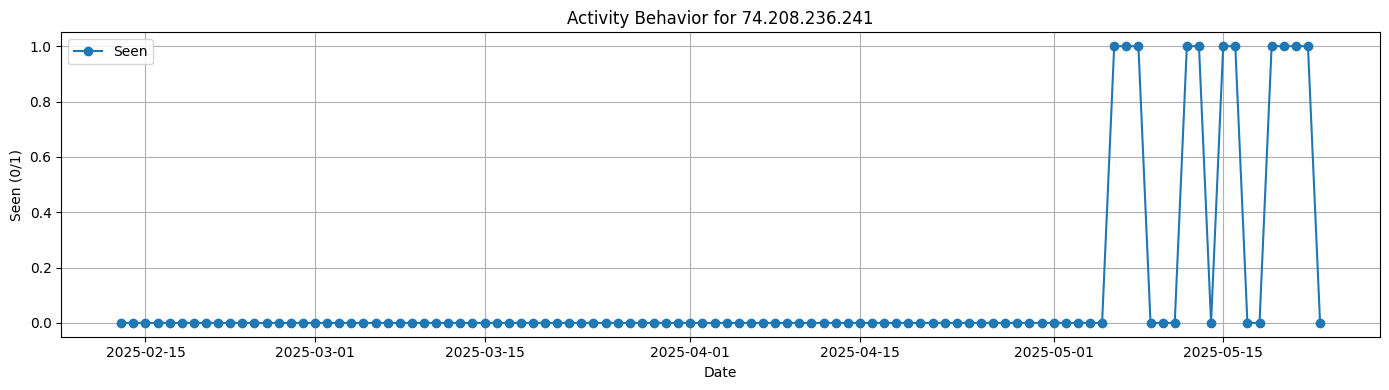

In [186]:
import matplotlib.pyplot as plt

indicator_id = '74.208.236.241'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [187]:
output[output['indicator'] == '113.96.236.11']

,indicator,seen_today,last_seen,freq_7,freq_30,avg_gap,burstiness,exp_today,exp_7,exp_14,...,weibull_14,weibull_30,logistic_today,logistic_7,logistic_14,logistic_30,gbt_today,gbt_7,gbt_14,gbt_30
16,113.96.236.11,0,64.0,0.0,0.0,1.75,-0.357033,9.999995e-07,0.000007,0.000014,...,1.744710e-07,0.000003,0.001748,0.001748,0.001858,0.023953,0.000018,0.000018,0.000021,0.000027


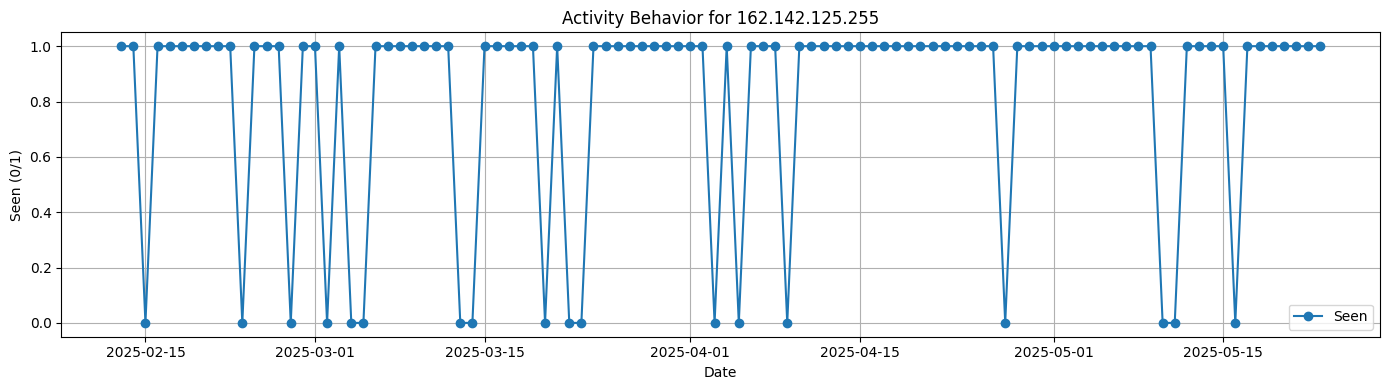

In [188]:
indicator_id = '162.142.125.255'
df_plot = df[df['indicator'] == indicator_id].sort_values('date')

plt.figure(figsize=(14, 4))
plt.plot(df_plot['date'], df_plot['seen'], marker='o', linestyle='-', label='Seen')
plt.title(f'Activity Behavior for {indicator_id}')
plt.xlabel('Date')
plt.ylabel('Seen (0/1)')
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [189]:
df[(df['seen'] ==0) & (df['date'] == pd.Timestamp('2025-05-21'))]

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
122596,818860012482918321,2025-05-21,102.129.153.43,0,2,False,21,5,0
122464,818860012482918321,2025-05-21,102.129.153.71,0,2,False,21,5,0
122614,818860012482918321,2025-05-21,102.165.16.161,0,2,False,21,5,0
122681,818860012482918321,2025-05-21,103.147.185.248,0,2,False,21,5,0
122693,818860012482918321,2025-05-21,103.207.37.51,0,2,False,21,5,0
...,...,...,...,...,...,...,...,...,...
122673,818860012482918321,2025-05-21,93.123.109.231,0,2,False,21,5,0
122607,818860012482918321,2025-05-21,hcmiu.edu.vn/,0,2,False,21,5,0
122563,818860012482918321,2025-05-21,international.standardbank.com/,0,2,False,21,5,0
122641,818860012482918321,2025-05-21,pub.marq.com/,0,2,False,21,5,0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import expon
import numpy as np

#  Define features and labels ---
features = ['last_seen', 'freq_7', 'freq_30', 'avg_gap', 'burstiness']
X = output[features]

#  Rule-Based Binary Labels Using last_seen ---
output['rule_today'] = output['last_seen'].apply(lambda x: 1 if x == 0 else 0)
output['rule_7d'] = output['last_seen'].apply(lambda x: 1 if x <= 6 else 0)
output['rule_14d'] = output['last_seen'].apply(lambda x: 1 if x <= 13 else 0)
output['rule_30d'] = output['last_seen'].apply(lambda x: 1 if x <= 29 else 0)

y_today = output['rule_today']
y_7 = output['rule_7d']
y_14 = output['rule_14d']
y_30 = output['rule_30d']

#  Logistic Regression Model ---
def train_logistic_model(X, y):
    if len(np.unique(y)) < 2:
        return np.full(len(y), np.nan)
    model = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression())
    ])
    model.fit(X, y)
    return model.predict_proba(X)[:, 1]

output['prob_today'] = train_logistic_model(X, y_today)
output['prob_7d'] = train_logistic_model(X, y_7)
output['prob_14d'] = train_logistic_model(X, y_14)
output['prob_30d'] = train_logistic_model(X, y_30)

#  Ensemble Probabilities ---
output['ensemble_7d'] = (
    0.3 * output['prob_7d'].astype(float) +
    0.25 * output['gbt_7'] +
    0.25 * output['weibull_7'] +
    0.3 * output['exp_7']
)

output['ensemble_14d'] = (
    0.3 * output['prob_14d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25* output['weibull_14'] +
    0.3 * output['exp_14']
)

output['ensemble_30d'] = (
    0.3 * output['prob_30d'].astype(float) +
    0.25 * output['gbt_14'] +
    0.25 * output['weibull_30'] +
    0.3 * output['exp_30']
)

#  Confidence Tags ---
def classify_window(prob, freq_7, high_thresh, label):
    if prob >= high_thresh and freq_7 >= 2:
        return f"{label}: Highly likely"
    elif prob >= 0.07 and freq_7 >= 1:
        return f"{label}: Possibly active"
    else:
        return f"{label}: Low confidence"

output['confidence_today'] = output.apply(
    lambda row: classify_window(
        float(row['prob_today'].strip('%')) / 100 if isinstance(row['prob_today'], str) else row['prob_today'],
        row['freq_7'], 0.6, 'Today'
    ), axis=1
)

output['confidence_7d'] = output.apply(
    lambda row: classify_window(
        float(row['ensemble_7d'].strip('%')) / 100 if isinstance(row['ensemble_7d'], str) else row['ensemble_7d'],
        row['freq_7'], 0.6, '7-Day'
    ), axis=1
)

output['confidence_14d'] = output.apply(
    lambda row: classify_window(
        float(row['ensemble_14d'].strip('%')) / 100 if isinstance(row['ensemble_14d'], str) else row['ensemble_14d'],
        row['freq_7'], 0.6, '14-Day'
    ), axis=1
)

output['confidence_30d'] = output.apply(
    lambda row: classify_window(
        float(row['ensemble_30d'].strip('%')) / 100 if isinstance(row['ensemble_30d'], str) else row['ensemble_30d'],
        row['freq_7'], 0.6, '30-Day'
    ), axis=1
)

#  Format Percentages ---
for col in ['prob_7d', 'prob_14d', 'prob_30d', 'ensemble_7d', 'ensemble_14d', 'ensemble_30d']:
    output[col] = (output[col] * 100).round(2).astype(str) + '%'

#  Format Today prob ---
output['prob_today'] = (output['prob_today'].astype(float) * 100).round(2).astype(str) + '%'

#  Final Output ---
production_output = output[[
    'indicator', 'seen_today', 'freq_7', 'freq_30',
    'prob_today', 'confidence_today',
    'ensemble_7d', 'confidence_7d',
    'ensemble_14d', 'confidence_14d',
    'ensemble_30d', 'confidence_30d'
]].copy()

# --- Rename for display ---
production_output.rename(columns={
    'indicator': 'Indicator',
    'seen_today': 'Observed Today',
    'freq_7': 'Frequency (7d)',
    'freq_30': 'Frequency (30d)',
    'prob_today': 'Probability: Today',
    'confidence_today': 'Confidence: Today',
    'ensemble_7d': 'Probability: 7-Day',
    'confidence_7d': 'Confidence: 7-Day',
    'ensemble_14d': 'Probability: 14-Day',
    'confidence_14d': 'Confidence: 14-Day',
    'ensemble_30d': 'Probability: 30-Day',
    'confidence_30d': 'Confidence: 30-Day'
}, inplace=True)

display(production_output)



,Indicator,Observed Today,Frequency (7d),Frequency (30d),Probability: Today,Confidence: Today,Probability: 7-Day,Confidence: 7-Day,Probability: 14-Day,Confidence: 14-Day,Probability: 30-Day,Confidence: 30-Day
0,102.129.153.158,0,1.0,1.0,9.14%,Today: Possibly active,57.93%,7-Day: Possibly active,66.96%,14-Day: Possibly active,93.34%,30-Day: Possibly active
1,102.129.153.43,0,0.0,2.0,1.79%,Today: Low confidence,16.29%,7-Day: Low confidence,63.23%,14-Day: Low confidence,90.56%,30-Day: Low confidence
2,102.129.153.71,0,0.0,1.0,0.25%,Today: Low confidence,7.21%,7-Day: Low confidence,13.96%,14-Day: Low confidence,39.49%,30-Day: Low confidence
3,102.165.16.161,0,0.0,0.0,0.21%,Today: Low confidence,0.27%,7-Day: Low confidence,0.67%,14-Day: Low confidence,7.19%,30-Day: Low confidence
4,103.147.185.248,0,1.0,1.0,25.63%,Today: Possibly active,59.25%,7-Day: Possibly active,64.83%,14-Day: Possibly active,73.73%,30-Day: Possibly active
...,...,...,...,...,...,...,...,...,...,...,...,...
237,international.standardbank.com/,0,0.0,0.0,0.21%,Today: Low confidence,0.01%,7-Day: Low confidence,0.0%,14-Day: Low confidence,0.01%,30-Day: Low confidence
238,pub.marq.com/,0,0.0,1.0,0.29%,Today: Low confidence,11.52%,7-Day: Low confidence,62.23%,14-Day: Low confidence,97.57%,30-Day: Low confidence
239,realinvestmentadvice.com/,0,1.0,3.0,1.28%,Today: Low confidence,73.63%,7-Day: Possibly active,100.14%,14-Day: Possibly active,108.26%,30-Day: Possibly active
240,www.emergencylighting.com/,0,1.0,1.0,24.89%,Today: Possibly active,59.1%,7-Day: Possibly active,64.67%,14-Day: Possibly active,73.63%,30-Day: Possibly active
